# Product-Specific Pricing Recommendation & Competitor Positioning Analysis

Notebook ini merupakan versi `.ipynb` dari script `00.group_task_arina.py`.

Struktur notebook:
1. Load library dan konfigurasi path
2. Quote-level preprocessing
3. Product-specific pricing recommendation
4. Competitor positioning analysis
5. Visualisasi dengan layout yang tidak terpotong
6. Export hasil ke Excel

Catatan label:
- `convert_to_order = 0` berarti **Success**
- `convert_to_order = 1` berarti **Fail**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ============================================================
# Notebook configuration
# ============================================================

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 14

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

BASE_DIR = Path("..")
DATA_PATH = BASE_DIR / "dataset" / "df_preprocessed.csv"

OUTPUT_DIR = BASE_DIR / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

def save_and_show(fig, filename=None, dpi=300):
    """Show plot neatly in notebook and optionally save it without cropped labels."""
    fig.tight_layout()
    if filename is not None:
        fig.savefig(FIGURE_DIR / filename, dpi=dpi, bbox_inches="tight")
    plt.show()

## 1. Aggregation Rule for Quote-Level Data

Bagian ini mempertahankan komponen agregasi dari script awal. Data item-level digabungkan menjadi quote-level, terutama untuk quote yang memiliki lebih dari satu product.

In [2]:
agg_dict = {
    "product": lambda x: "-".join(sorted(x)),
    "kw": "sum",
    "qty": "sum",
    "subtotal_price": "sum",
    "energy_grant_amount": "sum",
    "estimated_cost": "sum",
    "estimated_gross_profit": "sum",
    "unit_price": "mean",
    "gross_margin_rate": "mean",  # later complemented with weighted average
    "known_num_compe": "mean",
    "competitor_count_available": "mean",
    "avg_competitor_price": "mean",
    "min_competitor_price": "min",
    "max_competitor_price": "max",
    "price_gap_avg_competitor": "mean",
    "price_gap_avg_competitor_pct": "mean",
    "is_highest_price": "mean",
    "is_compe_a": "max",
    "is_compe_b": "max",
    "is_compe_c": "max",
    "higher_than_avg_competitor": "mean",
    "is_lower_than_competitor": "mean",
    "effective_price_after_grant": "sum",
    "grant_ratio_to_subtotal": "mean",
    "convert_to_order": "first"
}

## 2. Load Dataset and Clean Duplicate / System Error Rows

Bagian ini mengikuti logic script awal:
- Rename `Success` menjadi `convert_to_order`
- Cek duplicate product dalam quote yang sama
- Hapus quantity `0`
- Hapus duplicate rows

In [3]:
df_raw = pd.read_csv(DATA_PATH)
df_raw.rename(columns={"Success": "convert_to_order"}, inplace=True)

print("Raw dataset shape:", df_raw.shape)
df_raw.head()

Raw dataset shape: (4991, 35)


,quote_id,product,kw,unit_price,qty,subtotal_price,gross_margin_rate,convert_to_order,energy_grant_amount,competitor_a,competitor_b,competitor_c,price_order,is_highest_price,is_compe_a,is_compe_b,is_compe_c,known_num_compe,avg_compe_price,max_compe_price,min_compe_price,competitor_count_available,avg_competitor_price,min_competitor_price,max_competitor_price,price_gap_avg_competitor,price_gap_avg_competitor_pct,price_gap_min_competitor,price_gap_min_competitor_pct,higher_than_avg_competitor,is_lower_than_competitor,effective_price_after_grant,grant_ratio_to_subtotal,estimated_cost,estimated_gross_profit
0,Q-00114,W,11.0,136000.0,1,136000.0,0.0712,0,66000,NaN,NaN,NaN,1,1,False,False,False,0,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,70000.0,0.485294,126316.800,9683.200
1,Q-00119,H1,37.0,290000.0,2,580000.0,0.3079,0,222000,360000.0,NaN,NaN,1,1,True,False,False,1,360000.0,360000.0,360000.0,1,360000.0,360000.0,360000.0,-70000.0,-19.444444,-70000.0,-19.444444,0.0,True,358000.0,0.382759,401418.000,178582.000
2,Q-00161,Y,150.0,2379000.0,1,2379000.0,0.4224,1,720000,NaN,NaN,NaN,1,1,False,False,False,0,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1659000.0,0.302648,1374110.400,1004889.600
3,Q-00167,O1,75.0,775970.0,1,775970.0,0.4117,0,375000,760000.0,900000.0,NaN,1,1,True,True,False,2,830000.0,900000.0,760000.0,2,830000.0,760000.0,900000.0,-54030.0,-6.509639,15970.0,2.101316,0.0,True,400970.0,0.483266,456503.151,319466.849
4,Q-00214,I1,22.0,300000.0,1,300000.0,0.6787,0,132000,240000.0,NaN,NaN,1,1,True,False,False,1,240000.0,240000.0,240000.0,1,240000.0,240000.0,240000.0,60000.0,25.000000,60000.0,25.000000,1.0,False,168000.0,0.440000,96390.000,203610.000


In [4]:
# ============================================================
# Clean duplicate product inside the same quote ID
# ============================================================

group = {}
for q_id in df_raw["quote_id"].unique():
    row = df_raw[df_raw["quote_id"] == q_id]
    group[q_id] = row["product"].tolist()

cleaned_duplicate_data = df_raw.copy()

for key, val in group.items():
    duplicate_products = [x for x in set(val) if val.count(x) > 1]

    if len(duplicate_products) != 0:
        for product in duplicate_products:
            duplicate_data = df_raw[
                (df_raw["quote_id"] == key) &
                (df_raw["product"] == product)
            ]

            # Keep row with the highest subtotal price, following the original script logic.
            highest_subtotal_price = duplicate_data["subtotal_price"].max()
            lower_duplicate_data = duplicate_data[
                duplicate_data["subtotal_price"] < highest_subtotal_price
            ]

            cleaned_duplicate_data = cleaned_duplicate_data.drop(
                index=lower_duplicate_data.index
            )

# Remove product rows with qty = 0 because they are likely system errors.
data_null = cleaned_duplicate_data[cleaned_duplicate_data["qty"] == 0]
cleaned_data = cleaned_duplicate_data.drop(index=data_null.index)
cleaned_data = cleaned_data.drop_duplicates()

df_clean = cleaned_data.copy()

print("Cleaned dataset shape:", df_clean.shape)
df_clean.head()

Cleaned dataset shape: (4818, 35)


,quote_id,product,kw,unit_price,qty,subtotal_price,gross_margin_rate,convert_to_order,energy_grant_amount,competitor_a,competitor_b,competitor_c,price_order,is_highest_price,is_compe_a,is_compe_b,is_compe_c,known_num_compe,avg_compe_price,max_compe_price,min_compe_price,competitor_count_available,avg_competitor_price,min_competitor_price,max_competitor_price,price_gap_avg_competitor,price_gap_avg_competitor_pct,price_gap_min_competitor,price_gap_min_competitor_pct,higher_than_avg_competitor,is_lower_than_competitor,effective_price_after_grant,grant_ratio_to_subtotal,estimated_cost,estimated_gross_profit
0,Q-00114,W,11.0,136000.0,1,136000.0,0.0712,0,66000,NaN,NaN,NaN,1,1,False,False,False,0,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,70000.0,0.485294,126316.800,9683.200
1,Q-00119,H1,37.0,290000.0,2,580000.0,0.3079,0,222000,360000.0,NaN,NaN,1,1,True,False,False,1,360000.0,360000.0,360000.0,1,360000.0,360000.0,360000.0,-70000.0,-19.444444,-70000.0,-19.444444,0.0,True,358000.0,0.382759,401418.000,178582.000
2,Q-00161,Y,150.0,2379000.0,1,2379000.0,0.4224,1,720000,NaN,NaN,NaN,1,1,False,False,False,0,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1659000.0,0.302648,1374110.400,1004889.600
3,Q-00167,O1,75.0,775970.0,1,775970.0,0.4117,0,375000,760000.0,900000.0,NaN,1,1,True,True,False,2,830000.0,900000.0,760000.0,2,830000.0,760000.0,900000.0,-54030.0,-6.509639,15970.0,2.101316,0.0,True,400970.0,0.483266,456503.151,319466.849
4,Q-00214,I1,22.0,300000.0,1,300000.0,0.6787,0,132000,240000.0,NaN,NaN,1,1,True,False,False,1,240000.0,240000.0,240000.0,1,240000.0,240000.0,240000.0,60000.0,25.000000,60000.0,25.000000,1.0,False,168000.0,0.440000,96390.000,203610.000


## 3. Create Quote-Level Dataset

Quote yang memiliki beberapa product digabungkan menjadi satu baris quote-level.

In [5]:
count = df_clean["quote_id"].value_counts()
multi_product_data_ids = count[count >= 2].index.to_list()

multi_product_data = df_clean[
    df_clean["quote_id"].isin(multi_product_data_ids)
].reset_index(drop=True)

# Check whether each quote has uniform conversion outcome.
non_uniform_quote_ids = []
for ids in multi_product_data_ids:
    success_values = multi_product_data[
        multi_product_data["quote_id"] == ids
    ]["convert_to_order"].values

    uniform = len(set(success_values)) == 1
    if not uniform:
        non_uniform_quote_ids.append(ids)

print("Number of non-uniform quote IDs:", len(non_uniform_quote_ids))
non_uniform_quote_ids[:10]

Number of non-uniform quote IDs: 0


[]

In [6]:
quote_level = (
    multi_product_data
    .groupby("quote_id")
    .agg(agg_dict)
    .reset_index()
)

# Weighted gross margin rate by subtotal price.
weighted_margin = (
    multi_product_data
    .groupby("quote_id")
    .apply(lambda x: np.average(x["gross_margin_rate"], weights=x["subtotal_price"]))
    .reset_index(name="weighted_margin_rate")
)

quote_level = quote_level.merge(weighted_margin, on="quote_id", how="left")
df = quote_level.copy()

print("Quote-level dataset shape:", df.shape)
df.head()

Quote-level dataset shape: (160, 27)


C:\Users\surya\AppData\Local\Temp\ipykernel_7316\1564214541.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: np.average(x["gross_margin_rate"], weights=x["subtotal_price"]))


,quote_id,product,kw,qty,subtotal_price,energy_grant_amount,estimated_cost,estimated_gross_profit,unit_price,gross_margin_rate,known_num_compe,competitor_count_available,avg_competitor_price,min_competitor_price,max_competitor_price,price_gap_avg_competitor,price_gap_avg_competitor_pct,is_highest_price,is_compe_a,is_compe_b,is_compe_c,higher_than_avg_competitor,is_lower_than_competitor,effective_price_after_grant,grant_ratio_to_subtotal,convert_to_order,weighted_margin_rate
0,Q-00525,H1-I1,59.0,3,850000.0,354000,511445.00,338555.00,280000.0,0.3983,1.0,1.0,300000.0,240000.0,360000.0,-20000.0,-3.472222,1.0,True,False,False,0.5,0.5,496000.0,0.435824,0,0.3983
1,Q-02113,N1-N1,150.0,4,2872000.0,750000,1897530.40,974469.60,718000.0,0.3393,2.0,2.0,830000.0,760000.0,900000.0,-112000.0,-13.493976,1.0,True,True,False,0.0,1.0,2122000.0,0.261142,0,0.3393
2,Q-02428,O-S,185.0,2,1800900.0,850500,1056227.85,744672.15,900450.0,0.4135,0.5,0.5,1880000.0,1880000.0,1880000.0,-738100.0,-39.260638,1.0,True,False,False,0.0,0.5,950400.0,0.475883,0,0.4135
3,Q-03409,N1-N1,150.0,2,2567000.0,750000,901787.10,1665212.90,1283500.0,0.6487,2.0,2.0,830000.0,760000.0,900000.0,453500.0,54.638554,1.0,True,True,False,1.0,0.0,1817000.0,0.292170,1,0.6487
4,Q-03631,H1-N1,112.0,2,1009000.0,597000,610041.40,398958.60,504500.0,0.3954,1.5,1.5,595000.0,360000.0,900000.0,-90500.0,-10.903614,1.0,True,True,False,0.0,1.0,412000.0,0.597239,0,0.3954


## 4. Helper Columns for Conversion Outcome

In [7]:
df["success"] = np.where(df["convert_to_order"] == 0, 1, 0)
df["fail"] = np.where(df["convert_to_order"] == 1, 1, 0)

df["conversion_label"] = df["convert_to_order"].map({
    0: "Success",
    1: "Fail"
})

print("Overall success rate (%):", round(df["success"].mean() * 100, 2))
df["conversion_label"].value_counts()

Overall success rate (%): 50.0


conversion_label
Success    80
Fail       80
Name: count, dtype: int64

# Part A — Product-Specific Pricing Recommendation

## 5. Product-Level Summary

Tabel ini menunjukkan performa umum setiap product.

In [8]:
product_summary = df.groupby("product").agg(
    total_rows=("product", "count"),
    total_quote_id=("quote_id", "nunique"),
    success_rate=("success", "mean"),
    fail_rate=("fail", "mean"),
    avg_gmr=("gross_margin_rate", "mean"),
    median_gmr=("gross_margin_rate", "median"),
    avg_unit_price=("unit_price", "mean"),
    avg_qty=("qty", "mean"),
    avg_subtotal_price=("subtotal_price", "mean"),
    avg_energy_grant=("energy_grant_amount", "mean"),
    avg_competitor_price=("avg_competitor_price", "mean"),
    avg_price_gap_pct=("price_gap_avg_competitor_pct", "mean"),
    pct_higher_than_competitor=("higher_than_avg_competitor", "mean"),
    avg_estimated_profit=("estimated_gross_profit", "mean")
).reset_index()

# Convert proportions to percentages once.
for col in ["success_rate", "fail_rate", "pct_higher_than_competitor"]:
    product_summary[col] = product_summary[col] * 100

product_summary.sort_values("total_rows", ascending=False)

,product,total_rows,total_quote_id,success_rate,fail_rate,avg_gmr,median_gmr,avg_unit_price,avg_qty,avg_subtotal_price,avg_energy_grant,avg_competitor_price,avg_price_gap_pct,pct_higher_than_competitor,avg_estimated_profit
26,H1-I1,32,32,34.375000,65.625000,0.444219,0.42600,3.307763e+05,2.750000,8.419562e+05,354000.0,3.000000e+05,11.603809,78.125000,3.572204e+05
34,I1-I1,14,14,85.714286,14.285714,0.167371,0.12010,1.989645e+05,5.714286,1.056489e+06,264000.0,2.400000e+05,-17.098118,21.428571,1.340219e+05
31,H1-N1,13,13,23.076923,76.923077,0.441454,0.39540,5.945741e+05,2.615385,1.548041e+06,597000.0,5.950000e+05,4.358345,53.846154,7.783697e+05
22,H1-H1,12,12,91.666667,8.333333,0.392508,0.37000,3.346103e+05,3.166667,9.930716e+05,444000.0,3.600000e+05,-7.052685,33.333333,3.631619e+05
3,A1-I1,8,8,12.500000,87.500000,0.480562,0.44860,3.175538e+05,2.000000,6.351075e+05,222000.0,2.050000e+05,57.589338,100.000000,3.226866e+05
43,N1-N1,4,4,50.000000,50.000000,0.390550,0.34505,8.174690e+05,2.500000,1.993938e+06,750000.0,8.300000e+05,-1.509759,25.000000,8.455512e+05
59,W-W,4,4,50.000000,50.000000,0.165200,0.19515,1.727458e+05,6.000000,9.908575e+05,132000.0,NaN,NaN,NaN,1.664907e+05
55,Q-W,3,3,0.000000,100.000000,0.191433,0.06050,1.952500e+05,2.000000,3.905000e+05,111000.0,1.300000e+05,42.000000,100.000000,9.720168e+04
6,A1-W,3,3,33.333333,66.666667,0.204433,0.24960,1.926875e+05,3.333333,5.976183e+05,156000.0,1.700000e+05,20.747059,66.666667,1.019486e+05
17,E1-I,3,3,66.666667,33.333333,0.243467,0.26030,2.181572e+06,2.333333,5.020460e+06,1780000.0,2.000000e+06,21.216667,66.666667,1.298817e+06


## 6. Create Margin Group

Negative margin tetap dimasukkan untuk analisis, tetapi tidak dipakai sebagai rekomendasi normal.

In [9]:
margin_bins = [-np.inf, 0, 0.20, 0.30, 0.40, 0.50, 0.60, np.inf]

margin_labels = [
    "Negative",
    "0-20%",
    "20-30%",
    "30-40%",
    "40-50%",
    "50-60%",
    "60%+"
]

df["margin_group"] = pd.cut(
    df["gross_margin_rate"],
    bins=margin_bins,
    labels=margin_labels
)

df[[
    "product",
    "gross_margin_rate",
    "margin_group",
    "convert_to_order",
    "conversion_label"
]].head()

,product,gross_margin_rate,margin_group,convert_to_order,conversion_label
0,H1-I1,0.3983,30-40%,0,Success
1,N1-N1,0.3393,30-40%,0,Success
2,O-S,0.4135,40-50%,0,Success
3,N1-N1,0.6487,60%+,1,Fail
4,H1-N1,0.3954,30-40%,0,Success


## 7. Product × Margin Group Summary

In [10]:
product_margin_summary = df.groupby(
    ["product", "margin_group"],
    observed=False
).agg(
    total_rows=("product", "count"),
    total_quote_id=("quote_id", "nunique"),
    success_rate=("success", "mean"),
    fail_rate=("fail", "mean"),
    avg_gmr=("gross_margin_rate", "mean"),
    median_gmr=("gross_margin_rate", "median"),
    avg_unit_price=("unit_price", "mean"),
    avg_subtotal_price=("subtotal_price", "mean"),
    avg_energy_grant=("energy_grant_amount", "mean"),
    avg_competitor_price=("avg_competitor_price", "mean"),
    avg_price_gap_pct=("price_gap_avg_competitor_pct", "mean"),
    pct_higher_than_competitor=("higher_than_avg_competitor", "mean"),
    avg_estimated_profit=("estimated_gross_profit", "mean")
).reset_index()

for col in ["success_rate", "fail_rate", "pct_higher_than_competitor"]:
    product_margin_summary[col] = product_margin_summary[col] * 100

# Expected profit index combines success chance and estimated profit.
product_margin_summary["expected_profit_index"] = (
    product_margin_summary["success_rate"] / 100
) * product_margin_summary["avg_estimated_profit"]

product_margin_summary.sort_values(["product", "margin_group"])

,product,margin_group,total_rows,total_quote_id,success_rate,fail_rate,avg_gmr,median_gmr,avg_unit_price,avg_subtotal_price,avg_energy_grant,avg_competitor_price,avg_price_gap_pct,pct_higher_than_competitor,avg_estimated_profit,expected_profit_index
0,A-L,Negative,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,A-L,0-20%,1,1,100.0,0.0,0.0352,0.0352,170400.0,641400.0,275200.0,10500.0,282.857143,100.0,22577.28,22577.28
2,A-L,20-30%,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,A-L,30-40%,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,A-L,40-50%,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
415,W-W,20-30%,1,1,0.0,100.0,0.2191,0.2191,188500.0,377000.0,132000.0,NaN,NaN,NaN,82600.70,0.00
416,W-W,30-40%,1,1,0.0,100.0,0.3351,0.3351,182700.0,1827000.0,132000.0,NaN,NaN,NaN,612227.70,0.00
417,W-W,40-50%,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
418,W-W,50-60%,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 8. Keep Only Reliable Product-Margin Groups

In [11]:
MIN_PRODUCT_ROWS = 10
MIN_GROUP_ROWS = 5

reliable_products = product_summary[
    product_summary["total_rows"] >= MIN_PRODUCT_ROWS
]["product"]

reliable_product_margin = product_margin_summary[
    (product_margin_summary["product"].isin(reliable_products)) &
    (product_margin_summary["total_rows"] >= MIN_GROUP_ROWS)
].copy()

reliable_product_margin.sort_values(
    ["product", "expected_profit_index"],
    ascending=[True, False]
)

,product,margin_group,total_rows,total_quote_id,success_rate,fail_rate,avg_gmr,median_gmr,avg_unit_price,avg_subtotal_price,avg_energy_grant,avg_competitor_price,avg_price_gap_pct,pct_higher_than_competitor,avg_estimated_profit,expected_profit_index
186,H1-I1,40-50%,20,20,15.000000,85.000000,0.432555,0.42600,319585.020000,6.671700e+05,354000.0,300000.0,7.506764,97.500000,288235.762092,43235.364314
220,H1-N1,30-40%,6,6,33.333333,66.666667,0.377167,0.37855,517901.333333,1.035803e+06,597000.0,595000.0,-8.037236,41.666667,390824.501600,130274.833867
239,I1-I1,0-20%,10,10,100.000000,0.000000,0.098990,0.10320,179404.524000,1.280792e+06,264000.0,240000.0,-25.248115,0.000000,118487.885443,118487.885443


## 9. Select Recommended Margin Group for Each Product

In [12]:
normal_margin = reliable_product_margin[
    reliable_product_margin["margin_group"] != "Negative"
].copy()

best_margin_by_product = (
    normal_margin
    .sort_values(
        ["product", "expected_profit_index", "success_rate"],
        ascending=[True, False, False]
    )
    .groupby("product")
    .head(1)
    .reset_index(drop=True)
)

best_margin_by_product

,product,margin_group,total_rows,total_quote_id,success_rate,fail_rate,avg_gmr,median_gmr,avg_unit_price,avg_subtotal_price,avg_energy_grant,avg_competitor_price,avg_price_gap_pct,pct_higher_than_competitor,avg_estimated_profit,expected_profit_index
0,H1-I1,40-50%,20,20,15.000000,85.000000,0.432555,0.42600,319585.020000,6.671700e+05,354000.0,300000.0,7.506764,97.500000,288235.762092,43235.364314
1,H1-N1,30-40%,6,6,33.333333,66.666667,0.377167,0.37855,517901.333333,1.035803e+06,597000.0,595000.0,-8.037236,41.666667,390824.501600,130274.833867
2,I1-I1,0-20%,10,10,100.000000,0.000000,0.098990,0.10320,179404.524000,1.280792e+06,264000.0,240000.0,-25.248115,0.000000,118487.885443,118487.885443


## 10. Add Recommendation Notes

In [13]:
def pricing_recommendation(row):
    success_rate = row["success_rate"]
    margin_group = row["margin_group"]

    if success_rate >= 50 and margin_group in ["20-30%", "30-40%"]:
        return "Recommended: good balance between success rate and margin"
    elif success_rate >= 50 and margin_group == "0-20%":
        return "Competitive, but profitability should be monitored"
    elif success_rate >= 30 and margin_group in ["30-40%", "40-50%"]:
        return "Possible, but conversion risk should be monitored"
    elif success_rate < 20:
        return "Not ideal; high failure risk based on historical data"
    else:
        return "Acceptable, but needs case-by-case review"


def competitor_note(row):
    price_gap = row["avg_price_gap_pct"]

    if pd.isna(price_gap):
        return "Competitor data is limited"
    elif price_gap <= 0:
        return "Generally competitive compared to average competitor price"
    elif price_gap <= 10:
        return "Slightly above competitors; justify with value or service"
    else:
        return "Often above competitors; price review recommended"


best_margin_by_product["pricing_recommendation"] = best_margin_by_product.apply(
    pricing_recommendation,
    axis=1
)

best_margin_by_product["competitor_note"] = best_margin_by_product.apply(
    competitor_note,
    axis=1
)

best_margin_by_product[[
    "product",
    "margin_group",
    "total_rows",
    "total_quote_id",
    "success_rate",
    "fail_rate",
    "avg_gmr",
    "avg_unit_price",
    "avg_price_gap_pct",
    "pct_higher_than_competitor",
    "avg_estimated_profit",
    "expected_profit_index",
    "pricing_recommendation",
    "competitor_note"
]].sort_values("expected_profit_index", ascending=False)

,product,margin_group,total_rows,total_quote_id,success_rate,fail_rate,avg_gmr,avg_unit_price,avg_price_gap_pct,pct_higher_than_competitor,avg_estimated_profit,expected_profit_index,pricing_recommendation,competitor_note
1,H1-N1,30-40%,6,6,33.333333,66.666667,0.377167,517901.333333,-8.037236,41.666667,390824.501600,130274.833867,"Possible, but conversion risk should be monitored",Generally competitive compared to average comp...
2,I1-I1,0-20%,10,10,100.000000,0.000000,0.098990,179404.524000,-25.248115,0.000000,118487.885443,118487.885443,"Competitive, but profitability should be monit...",Generally competitive compared to average comp...
0,H1-I1,40-50%,20,20,15.000000,85.000000,0.432555,319585.020000,7.506764,97.500000,288235.762092,43235.364314,Not ideal; high failure risk based on historic...,Slightly above competitors; justify with value...


## 11. Final Recommendation Table

In [14]:
final_recommendation = best_margin_by_product.merge(
    product_summary,
    on="product",
    how="left",
    suffixes=("_recommended", "_overall")
)

final_table = final_recommendation[[
    "product",
    "margin_group",
    "total_rows_recommended",
    "total_quote_id_recommended",
    "success_rate_recommended",
    "fail_rate_recommended",
    "avg_gmr_recommended",
    "avg_unit_price_recommended",
    "avg_price_gap_pct_recommended",
    "pct_higher_than_competitor_recommended",
    "avg_estimated_profit_recommended",
    "expected_profit_index",
    "total_rows_overall",
    "total_quote_id_overall",
    "success_rate_overall",
    "avg_gmr_overall",
    "pricing_recommendation",
    "competitor_note"
]].copy()

final_table = final_table.rename(columns={
    "margin_group": "recommended_margin_group",
    "total_rows_recommended": "rows_in_recommended_group",
    "total_quote_id_recommended": "quote_ids_in_recommended_group",
    "success_rate_recommended": "success_rate_in_recommended_group",
    "fail_rate_recommended": "fail_rate_in_recommended_group",
    "avg_gmr_recommended": "avg_gmr_in_recommended_group",
    "avg_unit_price_recommended": "avg_unit_price_in_recommended_group",
    "avg_price_gap_pct_recommended": "avg_price_gap_pct_in_recommended_group",
    "pct_higher_than_competitor_recommended": "pct_higher_than_competitor_in_recommended_group",
    "avg_estimated_profit_recommended": "avg_estimated_profit_in_recommended_group",
    "total_rows_overall": "total_rows_product_overall",
    "total_quote_id_overall": "total_quote_id_product_overall",
    "success_rate_overall": "success_rate_product_overall",
    "avg_gmr_overall": "avg_gmr_product_overall"
})

final_table.sort_values("expected_profit_index", ascending=False)

,product,recommended_margin_group,rows_in_recommended_group,quote_ids_in_recommended_group,success_rate_in_recommended_group,fail_rate_in_recommended_group,avg_gmr_in_recommended_group,avg_unit_price_in_recommended_group,avg_price_gap_pct_in_recommended_group,pct_higher_than_competitor_in_recommended_group,avg_estimated_profit_in_recommended_group,expected_profit_index,total_rows_product_overall,total_quote_id_product_overall,success_rate_product_overall,avg_gmr_product_overall,pricing_recommendation,competitor_note
1,H1-N1,30-40%,6,6,33.333333,66.666667,0.377167,517901.333333,-8.037236,41.666667,390824.501600,130274.833867,13,13,23.076923,0.441454,"Possible, but conversion risk should be monitored",Generally competitive compared to average comp...
2,I1-I1,0-20%,10,10,100.000000,0.000000,0.098990,179404.524000,-25.248115,0.000000,118487.885443,118487.885443,14,14,85.714286,0.167371,"Competitive, but profitability should be monit...",Generally competitive compared to average comp...
0,H1-I1,40-50%,20,20,15.000000,85.000000,0.432555,319585.020000,7.506764,97.500000,288235.762092,43235.364314,32,32,34.375000,0.444219,Not ideal; high failure risk based on historic...,Slightly above competitors; justify with value...


## 12. Products with Insufficient Data

In [15]:
insufficient_products = product_summary[
    product_summary["total_rows"] < MIN_PRODUCT_ROWS
].copy()

insufficient_products["recommendation_note"] = (
    "Not enough data for product-specific recommendation. "
    "Use general pricing strategy or collect more data."
)

insufficient_products.sort_values("total_rows")

,product,total_rows,total_quote_id,success_rate,fail_rate,avg_gmr,median_gmr,avg_unit_price,avg_qty,avg_subtotal_price,avg_energy_grant,avg_competitor_price,avg_price_gap_pct,pct_higher_than_competitor,avg_estimated_profit,recommendation_note
0,A-L,1,1,100.000000,0.000000,0.035200,0.03520,1.704000e+05,3.000000,6.414000e+05,275200.0,1.050000e+04,282.857143,100.000000,2.257728e+04,Not enough data for product-specific recommend...
2,A1-H1-I1,1,1,100.000000,0.000000,0.327500,0.32750,2.521058e+05,4.000000,1.078535e+06,444000.0,2.566667e+05,1.643750,33.333333,3.532203e+05,Not enough data for product-specific recommend...
7,C-O-S,1,1,0.000000,100.000000,0.640700,0.64070,2.555667e+06,3.000000,7.667000e+06,1301500.0,1.880000e+06,81.914894,100.000000,4.912247e+06,Not enough data for product-specific recommend...
4,A1-I1-Q,1,1,100.000000,0.000000,0.268200,0.26820,2.053058e+05,4.000000,8.640041e+05,267000.0,1.800000e+05,15.819343,100.000000,2.317259e+05,Not enough data for product-specific recommend...
13,D-N-T,1,1,0.000000,100.000000,0.644900,0.64490,2.457900e+06,3.000000,7.373700e+06,1301500.0,1.880000e+06,81.914894,100.000000,4.755299e+06,Not enough data for product-specific recommend...
11,C1-J1,1,1,100.000000,0.000000,0.476300,0.47630,8.719800e+05,2.000000,1.743960e+06,949500.0,1.360000e+06,-28.553180,0.000000,8.306481e+05,Not enough data for product-specific recommend...
10,C1-G,1,1,100.000000,0.000000,0.150800,0.15080,1.313850e+06,2.000000,2.627700e+06,1383000.0,2.100000e+06,-38.595238,0.000000,3.962572e+05,Not enough data for product-specific recommend...
9,C-U,1,1,100.000000,0.000000,0.143900,0.14390,1.300000e+06,3.000000,3.700000e+06,979000.0,1.880000e+06,-20.212766,0.000000,5.324300e+05,Not enough data for product-specific recommend...
15,D1-F1,1,1,0.000000,100.000000,0.374900,0.37490,2.725500e+06,2.000000,5.451000e+06,1920000.0,2.000000e+06,36.275000,100.000000,2.043580e+06,Not enough data for product-specific recommend...
14,D-S,1,1,0.000000,100.000000,0.653200,0.65320,3.060500e+06,2.000000,6.121000e+06,979000.0,1.880000e+06,81.914894,100.000000,3.998237e+06,Not enough data for product-specific recommend...


## 13. Margin Group Color Palette

In [16]:
margin_palette = {
    "Negative": "#DEEBF7",
    "0-20%": "#C6DBEF",
    "20-30%": "#9ECAE1",
    "30-40%": "#6BAED6",
    "40-50%": "#4292C6",
    "50-60%": "#2171B5",
    "60%+": "#084594"
}

margin_order = [
    "Negative",
    "0-20%",
    "20-30%",
    "30-40%",
    "40-50%",
    "50-60%",
    "60%+"
]

## 14. Visualization — Recommended Margin Group and Success Rate by Product

Layout figure dibuat lebih lebar dan menggunakan `tight_layout()` + `bbox_inches="tight"` saat save agar label tidak terpotong.

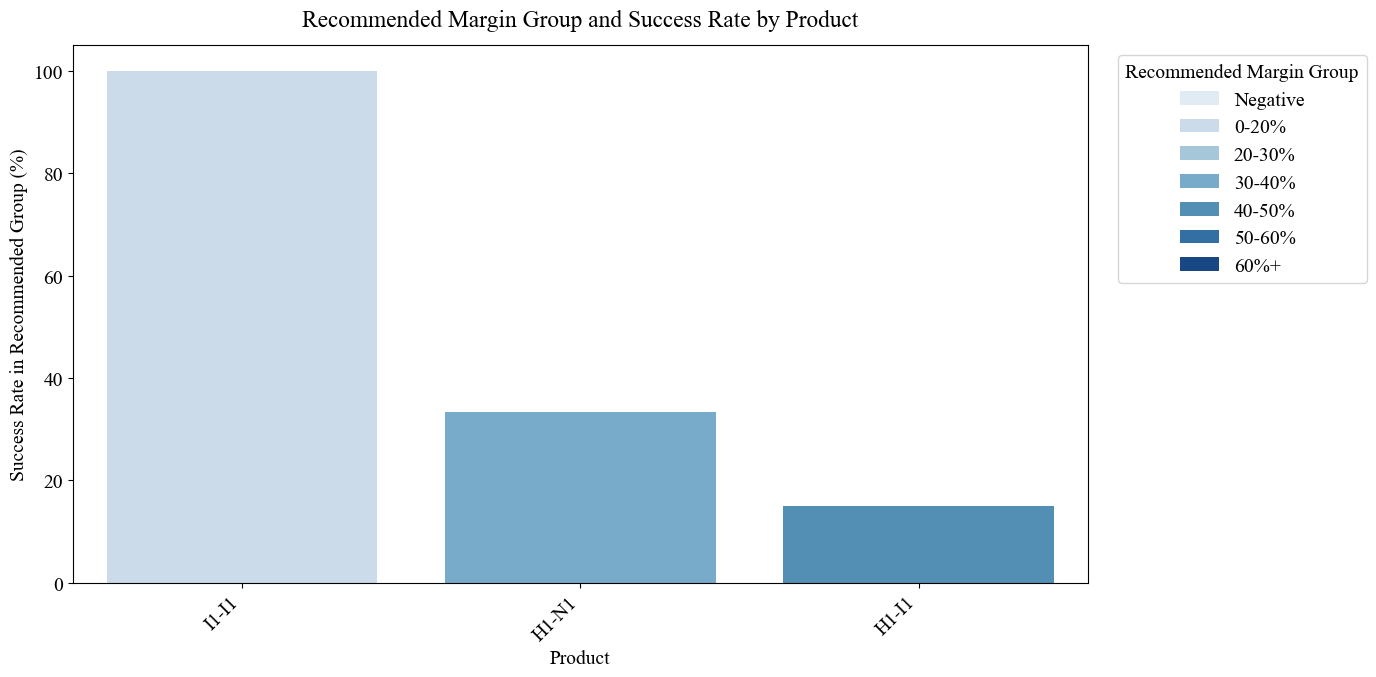

In [17]:
plot_df = final_table.sort_values(
    "success_rate_in_recommended_group",
    ascending=False
)

fig, ax = plt.subplots(figsize=(14, 7))

sns.barplot(
    data=plot_df,
    x="product",
    y="success_rate_in_recommended_group",
    hue="recommended_margin_group",
    hue_order=margin_order,
    palette=margin_palette,
    order=plot_df["product"].tolist(),
    ax=ax
)

ax.set_title("Recommended Margin Group and Success Rate by Product", pad=14)
ax.set_xlabel("Product")
ax.set_ylabel("Success Rate in Recommended Group (%)")
ax.tick_params(axis="x", rotation=45)
for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")

ax.legend(title="Recommended Margin Group", bbox_to_anchor=(1.02, 1), loc="upper left")

save_and_show(fig, "recommended_margin_success_rate_by_product.png")

## 15. Visualization — Expected Profit Index by Recommended Product Pricing Group

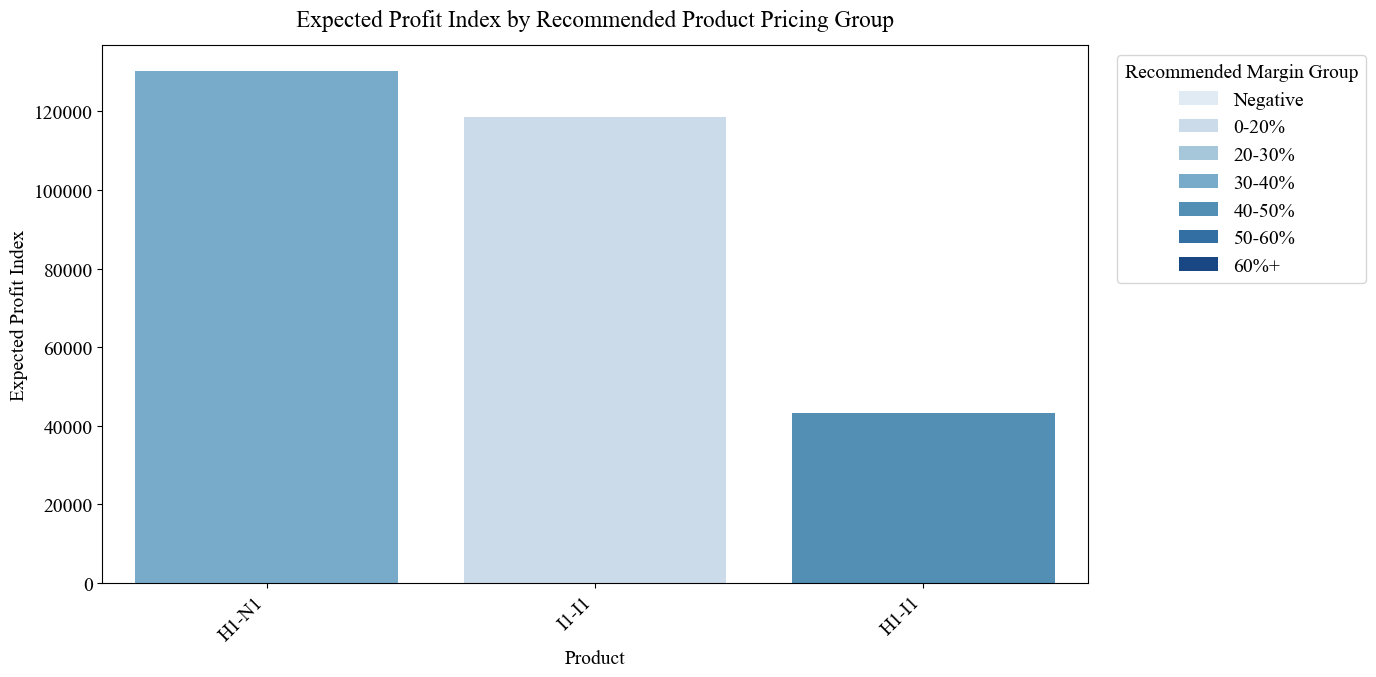

In [18]:
plot_df_profit = final_table.sort_values("expected_profit_index", ascending=False)

fig, ax = plt.subplots(figsize=(14, 7))

sns.barplot(
    data=plot_df_profit,
    x="product",
    y="expected_profit_index",
    hue="recommended_margin_group",
    hue_order=margin_order,
    palette=margin_palette,
    ax=ax
)

ax.set_title("Expected Profit Index by Recommended Product Pricing Group", pad=14)
ax.set_xlabel("Product")
ax.set_ylabel("Expected Profit Index")
ax.tick_params(axis="x", rotation=45)
for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")

ax.legend(title="Recommended Margin Group", bbox_to_anchor=(1.02, 1), loc="upper left")

save_and_show(fig, "expected_profit_index_by_recommended_group.png")

## 16. Export Product-Specific Pricing Recommendation Result

In [19]:
pricing_output_file = OUTPUT_DIR / "group_product_specific_pricing_recommendation.xlsx"

with pd.ExcelWriter(pricing_output_file, engine="openpyxl") as writer:
    product_summary.to_excel(writer, sheet_name="Product_Summary", index=False)
    product_margin_summary.to_excel(writer, sheet_name="Product_Margin_Summary", index=False)
    reliable_product_margin.to_excel(writer, sheet_name="Reliable_Product_Margin", index=False)
    final_table.to_excel(writer, sheet_name="Final_Recommendation", index=False)
    insufficient_products.to_excel(writer, sheet_name="Insufficient_Data", index=False)

print(f"Output saved as: {pricing_output_file}")

Output saved as: ..\outputs\group_product_specific_pricing_recommendation.xlsx


# Part B — Competitor Positioning Analysis

## 17. Dataset Check and Helper Columns

In [20]:
print("Dataset shape:", df.shape)
print(df.columns.tolist())

if "success" not in df.columns:
    df["success"] = np.where(df["convert_to_order"] == 0, 1, 0)

if "fail" not in df.columns:
    df["fail"] = np.where(df["convert_to_order"] == 1, 1, 0)

if "conversion_label" not in df.columns:
    df["conversion_label"] = df["convert_to_order"].map({
        0: "Success",
        1: "Fail"
    })

Dataset shape: (160, 31)
['quote_id', 'product', 'kw', 'qty', 'subtotal_price', 'energy_grant_amount', 'estimated_cost', 'estimated_gross_profit', 'unit_price', 'gross_margin_rate', 'known_num_compe', 'competitor_count_available', 'avg_competitor_price', 'min_competitor_price', 'max_competitor_price', 'price_gap_avg_competitor', 'price_gap_avg_competitor_pct', 'is_highest_price', 'is_compe_a', 'is_compe_b', 'is_compe_c', 'higher_than_avg_competitor', 'is_lower_than_competitor', 'effective_price_after_grant', 'grant_ratio_to_subtotal', 'convert_to_order', 'weighted_margin_rate', 'success', 'fail', 'conversion_label', 'margin_group']


## 18. Set Competitor Column Names

In [21]:
avg_comp_col = "avg_competitor_price" if "avg_competitor_price" in df.columns else "avg_compe_price"
min_comp_col = "min_competitor_price" if "min_competitor_price" in df.columns else "min_compe_price"
max_comp_col = "max_competitor_price" if "max_competitor_price" in df.columns else "max_compe_price"

gap_avg_col = "price_gap_avg_competitor_pct"
gap_min_col = "price_gap_min_competitor_pct"

print("Average competitor price column:", avg_comp_col)
print("Minimum competitor price column:", min_comp_col)
print("Maximum competitor price column:", max_comp_col)

Average competitor price column: avg_competitor_price
Minimum competitor price column: min_competitor_price
Maximum competitor price column: max_competitor_price


## 19. Create Competitor Position Category

In [22]:
def classify_price_position(row):
    gap = row[gap_avg_col]

    if pd.isna(gap):
        return "No Competitor Data"
    elif gap < -10:
        return "Much Lower than Competitor"
    elif -10 <= gap <= 0:
        return "Slightly Lower / Equal"
    elif 0 < gap <= 10:
        return "Slightly Higher"
    elif 10 < gap <= 30:
        return "Moderately Higher"
    else:
        return "Much Higher"

df["competitor_position"] = df.apply(classify_price_position, axis=1)

df[[
    "quote_id",
    "product",
    "unit_price",
    avg_comp_col,
    gap_avg_col,
    "competitor_position",
    "convert_to_order",
    "conversion_label"
]].head()

,quote_id,product,unit_price,avg_competitor_price,price_gap_avg_competitor_pct,competitor_position,convert_to_order,conversion_label
0,Q-00525,H1-I1,280000.0,300000.0,-3.472222,Slightly Lower / Equal,0,Success
1,Q-02113,N1-N1,718000.0,830000.0,-13.493976,Much Lower than Competitor,0,Success
2,Q-02428,O-S,900450.0,1880000.0,-39.260638,Much Lower than Competitor,0,Success
3,Q-03409,N1-N1,1283500.0,830000.0,54.638554,Much Higher,1,Fail
4,Q-03631,H1-N1,504500.0,595000.0,-10.903614,Much Lower than Competitor,0,Success


## 20. Overall Competitor Positioning Summary

In [23]:
position_summary = df.groupby("competitor_position").agg(
    total_rows=("competitor_position", "count"),
    total_quote_id=("quote_id", "nunique"),
    success_rate=("success", "mean"),
    fail_rate=("fail", "mean"),
    avg_unit_price=("unit_price", "mean"),
    avg_competitor_price=(avg_comp_col, "mean"),
    avg_price_gap_pct=(gap_avg_col, "mean"),
    median_price_gap_pct=(gap_avg_col, "median"),
    avg_gmr=("gross_margin_rate", "mean"),
    avg_qty=("qty", "mean"),
    avg_subtotal_price=("subtotal_price", "mean")
).reset_index()

position_summary["success_rate"] = position_summary["success_rate"] * 100
position_summary["fail_rate"] = position_summary["fail_rate"] * 100

position_order = [
    "Much Lower than Competitor",
    "Slightly Lower / Equal",
    "Slightly Higher",
    "Moderately Higher",
    "Much Higher",
    "No Competitor Data"
]

position_summary["competitor_position"] = pd.Categorical(
    position_summary["competitor_position"],
    categories=position_order,
    ordered=True
)

position_summary = position_summary.sort_values("competitor_position")
position_summary

,competitor_position,total_rows,total_quote_id,success_rate,fail_rate,avg_unit_price,avg_competitor_price,avg_price_gap_pct,median_price_gap_pct,avg_gmr,avg_qty,avg_subtotal_price
2,Much Lower than Competitor,49,49,89.795918,10.204082,553167.428367,738775.510204,-21.662126,-22.078000,0.246118,5.102041,2.162815e+06
5,Slightly Lower / Equal,21,21,52.380952,47.619048,600389.332540,643650.793651,-4.958057,-5.331250,0.379133,2.809524,1.484456e+06
4,Slightly Higher,27,27,22.222222,77.777778,343852.924074,333395.061728,5.335678,5.300000,0.425478,2.148148,7.297178e+05
0,Moderately Higher,20,20,35.000000,65.000000,457008.038333,396250.000000,17.055954,16.799672,0.324065,2.450000,1.119693e+06
1,Much Higher,32,32,15.625000,84.375000,888456.713542,617984.375000,67.710210,51.494277,0.506578,2.468750,2.194723e+06
3,No Competitor Data,11,11,63.636364,36.363636,849920.600455,NaN,NaN,NaN,0.280191,4.545455,3.900651e+06


## 21. Visualization — Success Rate by Competitor Price Position

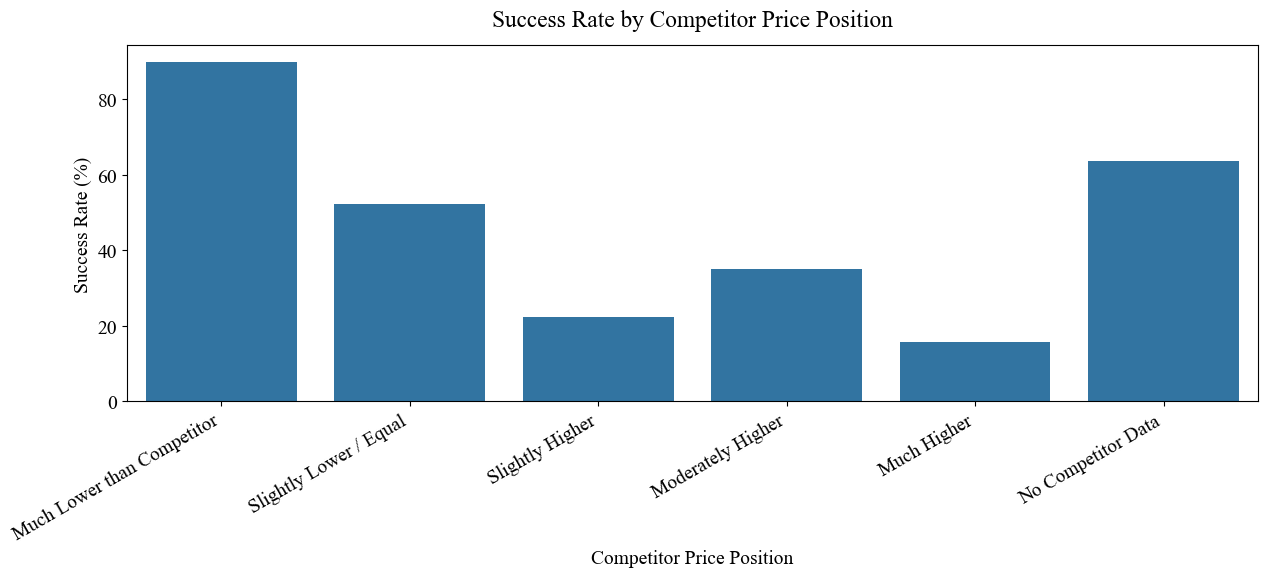

In [24]:
fig, ax = plt.subplots(figsize=(13, 6))

sns.barplot(
    data=position_summary,
    x="competitor_position",
    y="success_rate",
    order=position_order,
    ax=ax
)

ax.set_title("Success Rate by Competitor Price Position", pad=14)
ax.set_xlabel("Competitor Price Position")
ax.set_ylabel("Success Rate (%)")
ax.tick_params(axis="x", rotation=30)
for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")

save_and_show(fig, "success_rate_by_competitor_price_position.png")

## 22. Boxplot — Price Gap by Conversion Outcome

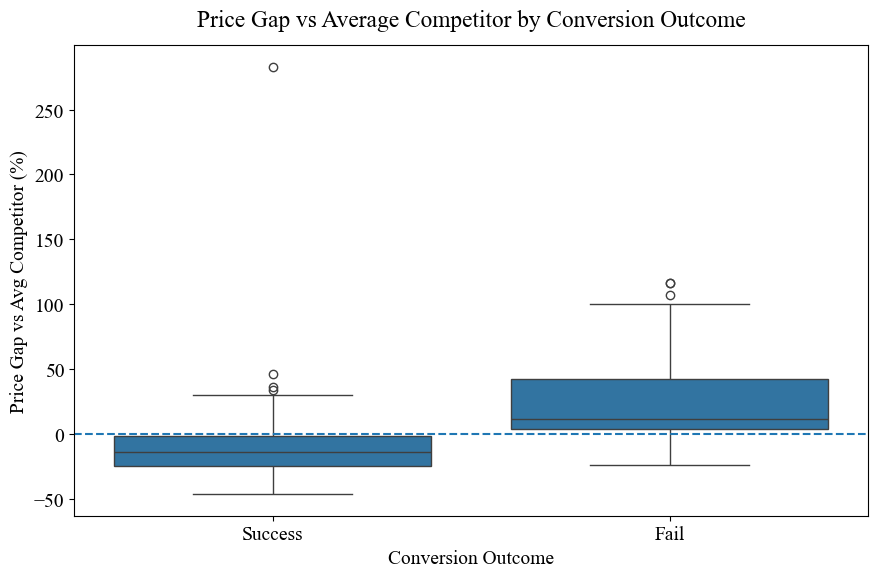

In [25]:
plot_data = df.dropna(subset=[gap_avg_col]).copy()

fig, ax = plt.subplots(figsize=(9, 6))

sns.boxplot(
    data=plot_data,
    x="conversion_label",
    y=gap_avg_col,
    ax=ax
)

ax.axhline(0, linestyle="--")
ax.set_title("Price Gap vs Average Competitor by Conversion Outcome", pad=14)
ax.set_xlabel("Conversion Outcome")
ax.set_ylabel("Price Gap vs Avg Competitor (%)")

save_and_show(fig, "price_gap_vs_avg_competitor_by_conversion_outcome.png")

## 23. Product-Level Competitor Positioning

In [26]:
product_competitor_summary = df.groupby("product").agg(
    total_rows=("product", "count"),
    total_quote_id=("quote_id", "nunique"),
    success_rate=("success", "mean"),
    avg_unit_price=("unit_price", "mean"),
    avg_competitor_price=(avg_comp_col, "mean"),
    avg_price_gap_pct=(gap_avg_col, "mean"),
    median_price_gap_pct=(gap_avg_col, "median"),
    pct_higher_than_competitor=("higher_than_avg_competitor", "mean"),
    avg_gmr=("gross_margin_rate", "mean"),
    avg_qty=("qty", "mean"),
    avg_subtotal_price=("subtotal_price", "mean")
).reset_index()

product_competitor_summary["success_rate"] = (
    product_competitor_summary["success_rate"] * 100
)

product_competitor_summary["pct_higher_than_competitor"] = (
    product_competitor_summary["pct_higher_than_competitor"] * 100
)

product_competitor_summary.sort_values(
    "avg_price_gap_pct",
    ascending=False
)

,product,total_rows,total_quote_id,success_rate,avg_unit_price,avg_competitor_price,avg_price_gap_pct,median_price_gap_pct,pct_higher_than_competitor,avg_gmr,avg_qty,avg_subtotal_price
0,A-L,1,1,100.000000,1.704000e+05,1.050000e+04,282.857143,282.857143,100.000000,0.035200,3.000000,6.414000e+05
13,D-N-T,1,1,0.000000,2.457900e+06,1.880000e+06,81.914894,81.914894,100.000000,0.644900,3.000000,7.373700e+06
14,D-S,1,1,0.000000,3.060500e+06,1.880000e+06,81.914894,81.914894,100.000000,0.653200,2.000000,6.121000e+06
7,C-O-S,1,1,0.000000,2.555667e+06,1.880000e+06,81.914894,81.914894,100.000000,0.640700,3.000000,7.667000e+06
48,N1-Q,1,1,0.000000,6.520000e+05,4.800000e+05,62.891566,62.891566,100.000000,0.546100,2.000000,1.304000e+06
40,M1-M1,1,1,0.000000,9.914240e+05,6.200000e+05,59.907097,59.907097,100.000000,0.549500,2.000000,1.982848e+06
3,A1-I1,8,8,12.500000,3.175538e+05,2.050000e+05,57.589338,33.003235,100.000000,0.480562,2.000000,6.351075e+05
5,A1-Q,3,3,0.000000,2.358908e+05,1.500000e+05,56.225980,33.004412,100.000000,0.312900,2.000000,4.717817e+05
18,E1-L1-Q1,1,1,100.000000,1.605195e+06,1.310000e+06,46.355726,46.355726,100.000000,0.344400,4.000000,5.760535e+06
55,Q-W,3,3,0.000000,1.952500e+05,1.300000e+05,42.000000,13.000000,100.000000,0.191433,2.000000,3.905000e+05


## 24. Reliable Product Competitor Positioning

In [27]:
MIN_PRODUCT_ROWS = 10

reliable_product_competitor = product_competitor_summary[
    product_competitor_summary["total_rows"] >= MIN_PRODUCT_ROWS
].copy()

reliable_product_competitor.sort_values(
    "avg_price_gap_pct",
    ascending=False
)

,product,total_rows,total_quote_id,success_rate,avg_unit_price,avg_competitor_price,avg_price_gap_pct,median_price_gap_pct,pct_higher_than_competitor,avg_gmr,avg_qty,avg_subtotal_price
26,H1-I1,32,32,34.375000,330776.336875,300000.0,11.603809,6.312500,78.125000,0.444219,2.750000,8.419562e+05
31,H1-N1,13,13,23.076923,594574.119231,595000.0,4.358345,-5.464608,53.846154,0.441454,2.615385,1.548041e+06
22,H1-H1,12,12,91.666667,334610.333333,360000.0,-7.052685,-8.794778,33.333333,0.392508,3.166667,9.930716e+05
34,I1-I1,14,14,85.714286,198964.517143,240000.0,-17.098118,-23.550250,21.428571,0.167371,5.714286,1.056489e+06


## 25. Visualization — Average Price Gap by Product

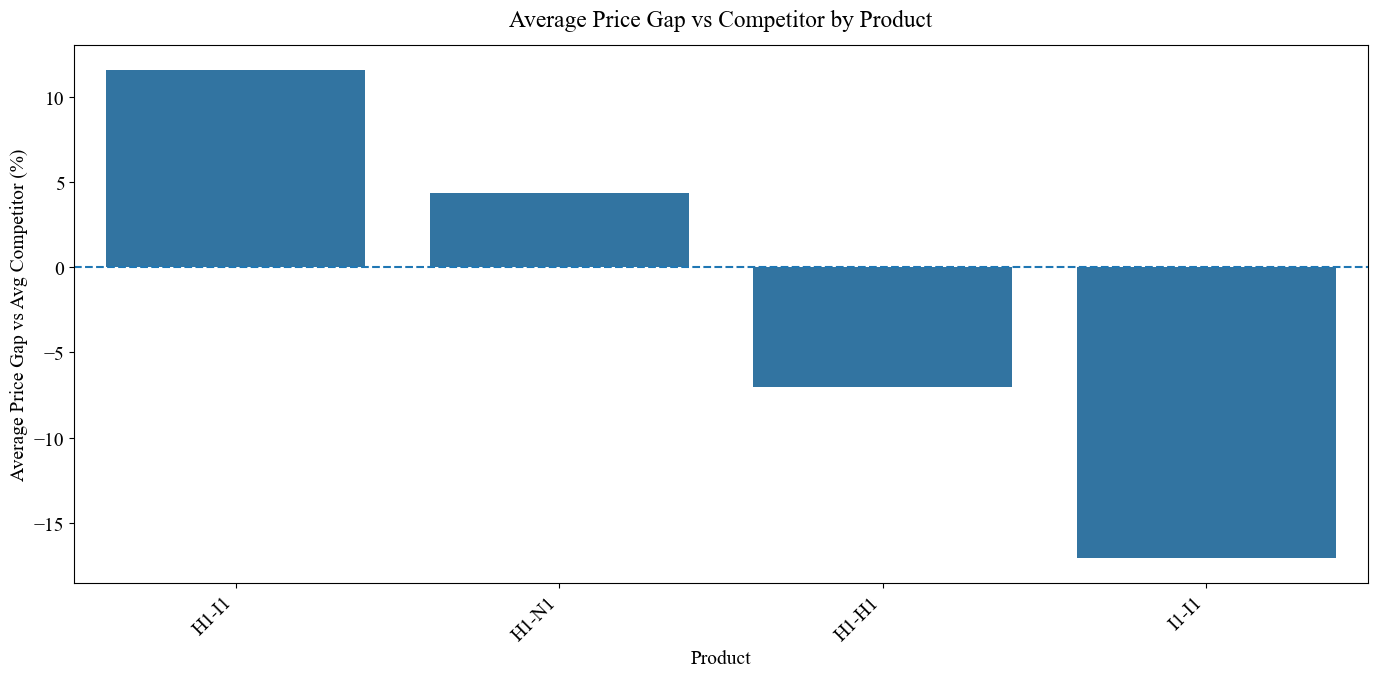

In [28]:
fig, ax = plt.subplots(figsize=(14, 7))

sns.barplot(
    data=reliable_product_competitor.sort_values("avg_price_gap_pct", ascending=False),
    x="product",
    y="avg_price_gap_pct",
    ax=ax
)

ax.axhline(0, linestyle="--")
ax.set_title("Average Price Gap vs Competitor by Product", pad=14)
ax.set_xlabel("Product")
ax.set_ylabel("Average Price Gap vs Avg Competitor (%)")
ax.tick_params(axis="x", rotation=45)
for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")

save_and_show(fig, "average_price_gap_vs_competitor_by_product.png")

## 26. Product × Competitor Position Summary

In [29]:
product_position_summary = df.groupby(["product", "competitor_position"]).agg(
    total_rows=("product", "count"),
    total_quote_id=("quote_id", "nunique"),
    success_rate=("success", "mean"),
    fail_rate=("fail", "mean"),
    avg_unit_price=("unit_price", "mean"),
    avg_competitor_price=(avg_comp_col, "mean"),
    avg_price_gap_pct=(gap_avg_col, "mean"),
    avg_gmr=("gross_margin_rate", "mean"),
    avg_qty=("qty", "mean"),
    avg_subtotal_price=("subtotal_price", "mean")
).reset_index()

product_position_summary["success_rate"] = product_position_summary["success_rate"] * 100
product_position_summary["fail_rate"] = product_position_summary["fail_rate"] * 100

product_position_summary.sort_values(
    ["product", "competitor_position"]
)

,product,competitor_position,total_rows,total_quote_id,success_rate,fail_rate,avg_unit_price,avg_competitor_price,avg_price_gap_pct,avg_gmr,avg_qty,avg_subtotal_price
0,A-L,Much Higher,1,1,100.0,0.0,170400.00,1.050000e+04,282.857143,0.035200,3.0,641400.00
1,A1-H1,Much Higher,2,2,50.0,50.0,346250.00,2.650000e+05,38.480392,0.455000,3.0,1112500.00
2,A1-H1-I1,Slightly Higher,1,1,100.0,0.0,252105.75,2.566667e+05,1.643750,0.327500,4.0,1078535.25
3,A1-I1,Moderately Higher,3,3,0.0,100.0,246186.00,2.050000e+05,22.172353,0.396833,2.0,492372.00
4,A1-I1,Much Higher,5,5,20.0,80.0,360374.40,2.050000e+05,78.839529,0.530800,2.0,720748.80
...,...,...,...,...,...,...,...,...,...,...,...,...
78,Q-W,Much Higher,1,1,0.0,100.0,275000.00,1.300000e+05,100.000000,0.472900,2.0,550000.00
79,R-X,Much Lower than Competitor,1,1,100.0,0.0,108587.85,1.300000e+05,-24.120000,0.055500,16.0,1637967.10
80,U-U,Much Lower than Competitor,1,1,100.0,0.0,1472681.00,1.880000e+06,-21.665904,0.282900,2.0,2945362.00
81,V-V,Much Lower than Competitor,1,1,100.0,0.0,1379970.00,1.880000e+06,-26.597340,0.270200,2.0,2759940.00


## 27. Reliable Product × Competitor Position Summary

In [30]:
MIN_GROUP_ROWS = 5

reliable_product_position = product_position_summary[
    (product_position_summary["product"].isin(reliable_product_competitor["product"])) &
    (product_position_summary["total_rows"] >= MIN_GROUP_ROWS)
].copy()

reliable_product_position.sort_values(
    ["product", "success_rate"],
    ascending=[True, False]
)

,product,competitor_position,total_rows,total_quote_id,success_rate,fail_rate,avg_unit_price,avg_competitor_price,avg_price_gap_pct,avg_gmr,avg_qty,avg_subtotal_price
28,H1-H1,Much Lower than Competitor,6,6,100.000000,0.000000,287874.000000,360000.0,-20.035000,0.294400,4.333333,1.223450e+06
38,H1-I1,Slightly Higher,17,17,5.882353,94.117647,316597.200000,300000.0,6.499428,0.426747,2.117647,6.661356e+05
48,H1-N1,Slightly Lower / Equal,5,5,20.000000,80.000000,528824.950000,595000.0,-6.399436,0.383280,2.000000,1.057650e+06
52,I1-I1,Much Lower than Competitor,11,11,100.000000,0.000000,181474.658182,240000.0,-24.385559,0.108309,6.727273,1.201116e+06


## 28. Heatmap — Success Rate by Product and Competitor Price Position

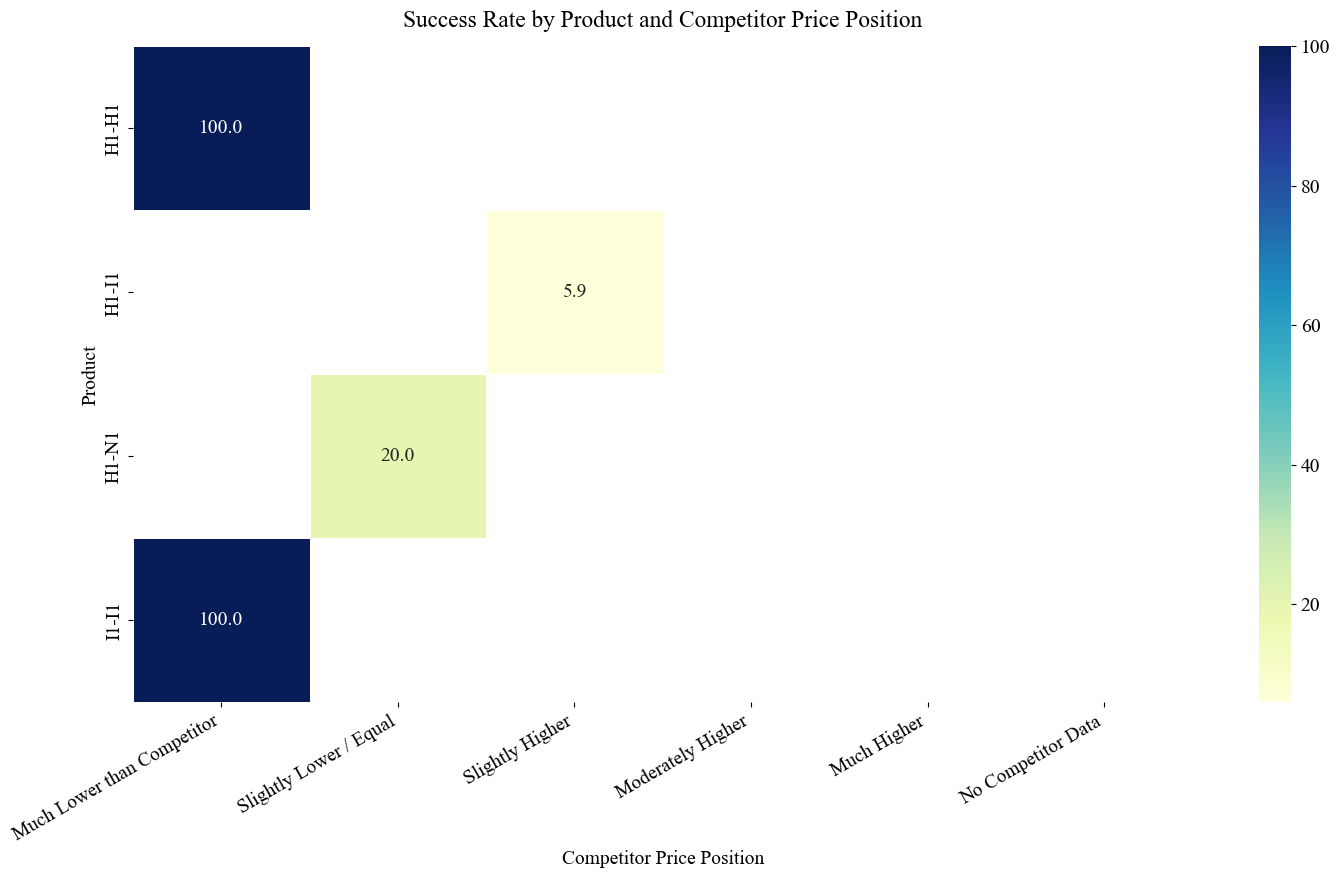

In [31]:
heatmap_data = reliable_product_position.pivot_table(
    index="product",
    columns="competitor_position",
    values="success_rate",
    aggfunc="mean"
)

heatmap_data = heatmap_data.reindex(columns=position_order)

fig, ax = plt.subplots(figsize=(15, 9))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.5,
    ax=ax
)

ax.set_title("Success Rate by Product and Competitor Price Position", pad=14)
ax.set_xlabel("Competitor Price Position")
ax.set_ylabel("Product")
ax.tick_params(axis="x", rotation=30)
for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")

save_and_show(fig, "success_rate_heatmap_by_product_and_competitor_position.png")

## 29. Competitor Position Summary Only

In [32]:
competitor_position_summary = df.groupby("competitor_position").agg(
    total_rows=("quote_id", "count"),
    total_quote_id=("quote_id", "nunique"),
    success_rate=("success", "mean"),
    avg_gmr=("gross_margin_rate", "mean"),
    avg_price_gap_pct=(gap_avg_col, "mean")
).reset_index()

competitor_position_summary["success_rate"] = (
    competitor_position_summary["success_rate"] * 100
)

competitor_position_summary["competitor_position"] = pd.Categorical(
    competitor_position_summary["competitor_position"],
    categories=position_order,
    ordered=True
)

competitor_position_summary = competitor_position_summary.sort_values(
    "competitor_position"
)

competitor_position_summary

,competitor_position,total_rows,total_quote_id,success_rate,avg_gmr,avg_price_gap_pct
2,Much Lower than Competitor,49,49,89.795918,0.246118,-21.662126
5,Slightly Lower / Equal,21,21,52.380952,0.379133,-4.958057
4,Slightly Higher,27,27,22.222222,0.425478,5.335678
0,Moderately Higher,20,20,35.000000,0.324065,17.055954
1,Much Higher,32,32,15.625000,0.506578,67.710210
3,No Competitor Data,11,11,63.636364,0.280191,NaN


## 30. Visualization — Success Rate by Competitor Position Only

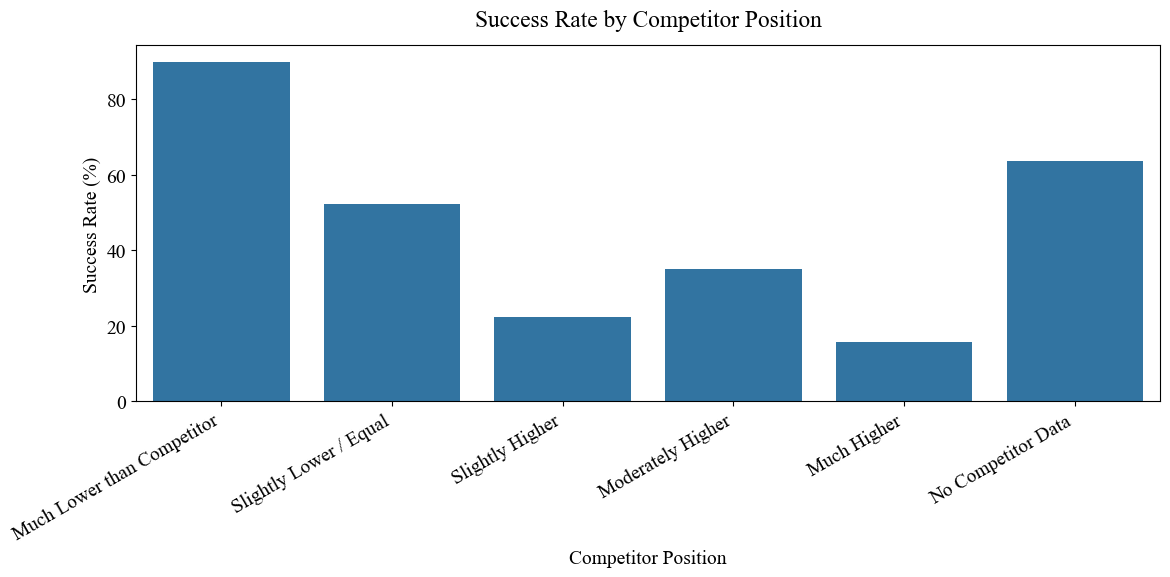

In [33]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=competitor_position_summary,
    x="competitor_position",
    y="success_rate",
    order=position_order,
    ax=ax
)

ax.set_title("Success Rate by Competitor Position", pad=14)
ax.set_xlabel("Competitor Position")
ax.set_ylabel("Success Rate (%)")
ax.tick_params(axis="x", rotation=30)
for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")

save_and_show(fig, "success_rate_by_competitor_position_only.png")

## 31. Final Competitor Positioning Recommendation Table

In [34]:
def competitor_position_recommendation(row):
    success_rate = row["success_rate"]
    price_gap = row["avg_price_gap_pct"]

    if pd.isna(price_gap):
        return "Competitor data is limited; improve competitor price collection"
    elif price_gap <= 0 and success_rate >= 40:
        return "Strong position: maintain competitive pricing"
    elif price_gap <= 0 and success_rate < 40:
        return "Price is competitive, but other factors may reduce success"
    elif price_gap > 0 and success_rate >= 40:
        return "Potential premium position: justify higher price with value/service"
    elif price_gap > 0 and success_rate < 30:
        return "Weak position: review price or strengthen value proposition"
    else:
        return "Monitor position case by case"


competitor_position_final = reliable_product_competitor.copy()

competitor_position_final["positioning_recommendation"] = competitor_position_final.apply(
    competitor_position_recommendation,
    axis=1
)

competitor_position_final.sort_values(
    ["avg_price_gap_pct", "success_rate"],
    ascending=[False, False]
)

,product,total_rows,total_quote_id,success_rate,avg_unit_price,avg_competitor_price,avg_price_gap_pct,median_price_gap_pct,pct_higher_than_competitor,avg_gmr,avg_qty,avg_subtotal_price,positioning_recommendation
26,H1-I1,32,32,34.375000,330776.336875,300000.0,11.603809,6.312500,78.125000,0.444219,2.750000,8.419562e+05,Monitor position case by case
31,H1-N1,13,13,23.076923,594574.119231,595000.0,4.358345,-5.464608,53.846154,0.441454,2.615385,1.548041e+06,Weak position: review price or strengthen valu...
22,H1-H1,12,12,91.666667,334610.333333,360000.0,-7.052685,-8.794778,33.333333,0.392508,3.166667,9.930716e+05,Strong position: maintain competitive pricing
34,I1-I1,14,14,85.714286,198964.517143,240000.0,-17.098118,-23.550250,21.428571,0.167371,5.714286,1.056489e+06,Strong position: maintain competitive pricing


## 32. Export Competitor Positioning Analysis Result

In [35]:
competitor_output_file = OUTPUT_DIR / "competitor_positioning_analysis.xlsx"

with pd.ExcelWriter(competitor_output_file, engine="openpyxl") as writer:
    position_summary.to_excel(writer, sheet_name="Overall_Position", index=False)
    product_competitor_summary.to_excel(writer, sheet_name="Product_Position", index=False)
    reliable_product_competitor.to_excel(writer, sheet_name="Reliable_Product_Position", index=False)
    product_position_summary.to_excel(writer, sheet_name="Product_x_Position", index=False)
    reliable_product_position.to_excel(writer, sheet_name="Reliable_Product_x_Position", index=False)
    competitor_position_summary.to_excel(writer, sheet_name="Competitor_Position", index=False)
    competitor_position_final.to_excel(writer, sheet_name="Final_Recommendation", index=False)

print(f"Output saved as: {competitor_output_file}")

Output saved as: ..\outputs\competitor_positioning_analysis.xlsx


## 33. Output Files

Setelah notebook dijalankan, output akan tersimpan di folder `output/`:
- `product_specific_pricing_recommendation.xlsx`
- `competitor_positioning_analysis.xlsx`

Gambar visualisasi juga akan tersimpan di:
- `output/figures/`